Investigação
---

*600 promoções realizadas nos últimos anos*

> Mulheres demoram mais para ser promovidas? Compare o meses_no_cargo_anterior entre homens e mulheres no histórico de promoções.

> No histórico de promoções, compare meses_no_cargo_anterior por sexo — mulheres esperam ~40% mais?

> Funcionários com satisfação ≤ 2 e sem promoção são os mais propensos a sair









`Importação das bibliotecas`

In [1]:
# Bibliotecas principais
import pandas as pd
import numpy as np

# Visualização
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

`Carregar os datasets`

In [8]:
df_historico_promocoes = pd.read_csv("/projeto_07_historico_promocoes (1).csv")

In [9]:
df_historico_promocoes.head(600)

df_historico_promocoes["Ano"] = df_historico_promocoes["meses_no_cargo_anterior"]/12
df_historico_promocoes["Ano"] = df_historico_promocoes["Ano"].round()
print(df_historico_promocoes)

    funcionario_id sexo departamento cargo_anterior   cargo_novo  \
0        FUN-00705    F      Produto         Sênior  Coordenador   
1        FUN-00334    M      Produto         Júnior        Pleno   
2        FUN-00380    M    Marketing          Pleno       Sênior   
3        FUN-00953    F           RH         Júnior        Pleno   
4        FUN-00463    M   Financeiro         Sênior  Coordenador   
..             ...  ...          ...            ...          ...   
595      FUN-01100    M   Engenharia         Júnior        Pleno   
596      FUN-00708    F       Vendas         Júnior        Pleno   
597      FUN-00966    F           RH         Júnior        Pleno   
598      FUN-00408    F       Vendas         Júnior        Pleno   
599      FUN-00298    F       Vendas         Júnior        Pleno   

    data_promocao  meses_no_cargo_anterior  salario_anterior  salario_novo  \
0      2021-08-02                       36          10535.55      12261.65   
1      2021-01-13          

`Limpeza de dados`

In [ ]:
df_historico_promocoes["data_promocao"] = pd.to_datetime(df_historico_promocoes["data_promocao"], errors="coerce")

df_historico_promocoes["sexo"] = df_historico_promocoes["sexo"].astype("category")
df_historico_promocoes["departamento"] = df_historico_promocoes["departamento"].astype("category")

`Detectar outliers`

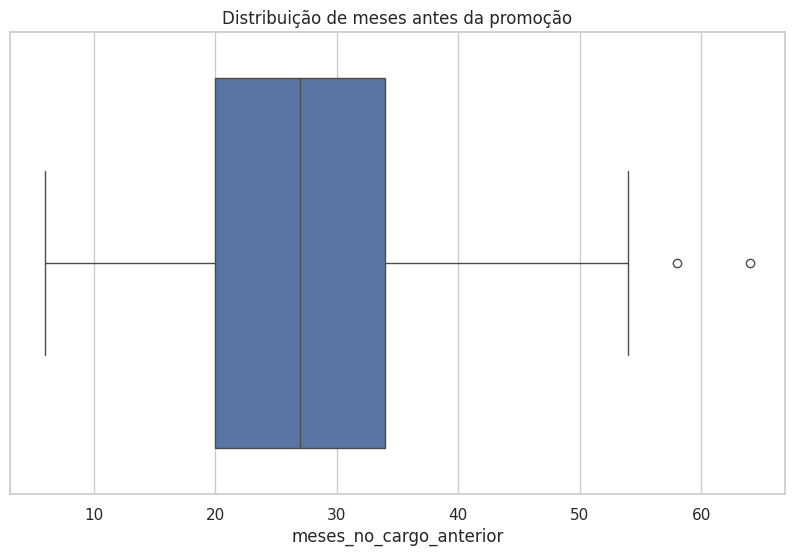

In [10]:
sns.boxplot(x=df_historico_promocoes["meses_no_cargo_anterior"])
plt.title("Distribuição de meses antes da promoção")
plt.show()
df_historico_promocoes = df_historico_promocoes[df_historico_promocoes["meses_no_cargo_anterior"] < 120]

`Hipótese de gênero`

In [11]:
# Mulheres esperam mais tempo para serem promovidas?

tempo_promocao = df_historico_promocoes.groupby("sexo")["Ano"].agg(
    media="mean",
    mediana="median",
    desvio="std",
    quantidade="count"
)
#inserir código para os gráficos
tempo_promocao

,media,mediana,desvio,quantidade
sexo,,,,
F,2.645390,3.0,0.869693,282
M,1.902516,2.0,0.719222,318


`Boxplot comparativo`

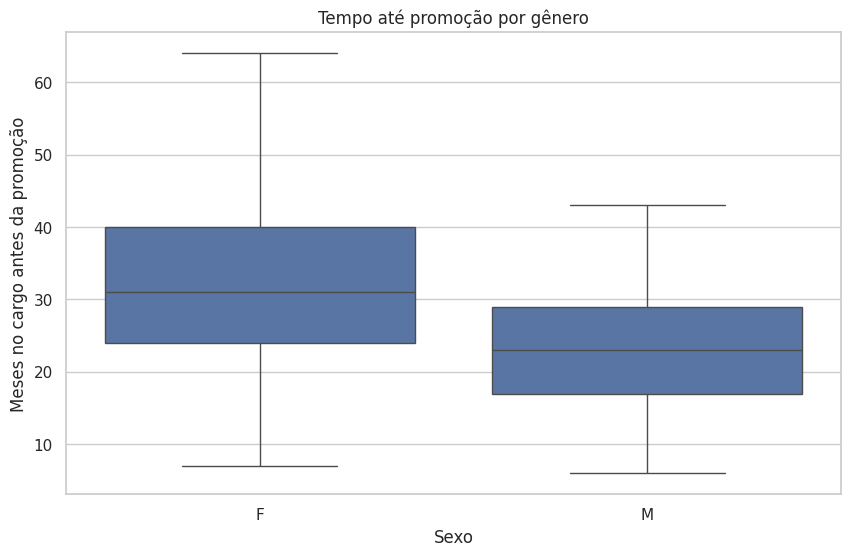

In [12]:
# Esse gráfico revela rapidamente desigualdade estrutural.

sns.boxplot(
    data=df_historico_promocoes,
    x="sexo",
    y="meses_no_cargo_anterior"
)

plt.title("Tempo até promoção por gênero")
plt.xlabel("Sexo")
plt.ylabel("Meses no cargo antes da promoção")

plt.show()

`Violinplot`

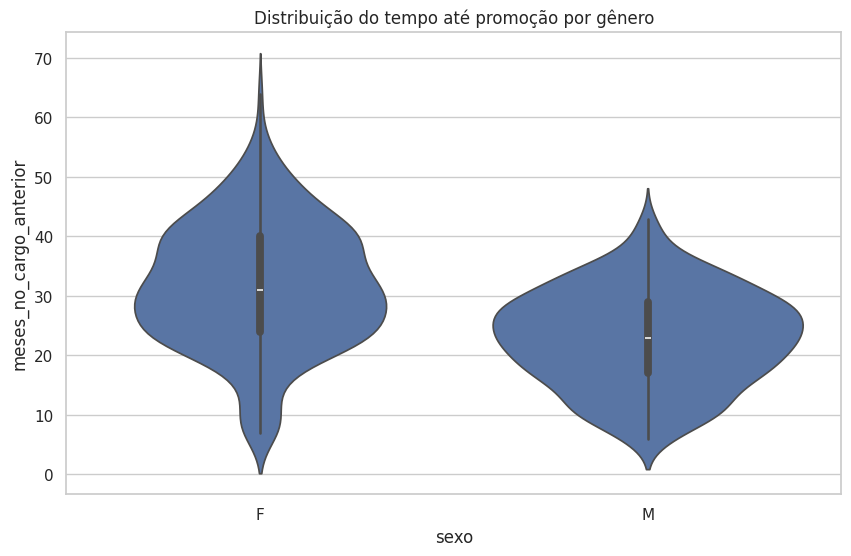

In [16]:
sns.violinplot(
    data=df_historico_promocoes,
    x="sexo",
    y="meses_no_cargo_anterior"
)

plt.title("Distribuição do tempo até promoção por gênero")

plt.show()

`Promoções por gênero`

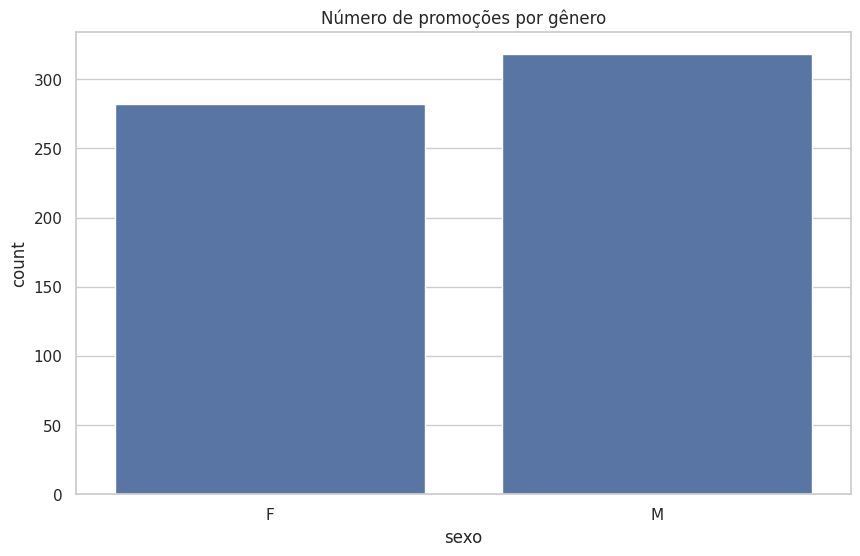

In [ ]:
sns.countplot(
    data=df_historico_promocoes,
    x="sexo"
)

plt.title("Número de promoções por gênero")
plt.show()

`Análise por departamento`

/tmp/ipykernel_735/2482224296.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tempo_departamento = df_historico_promocoes.groupby(


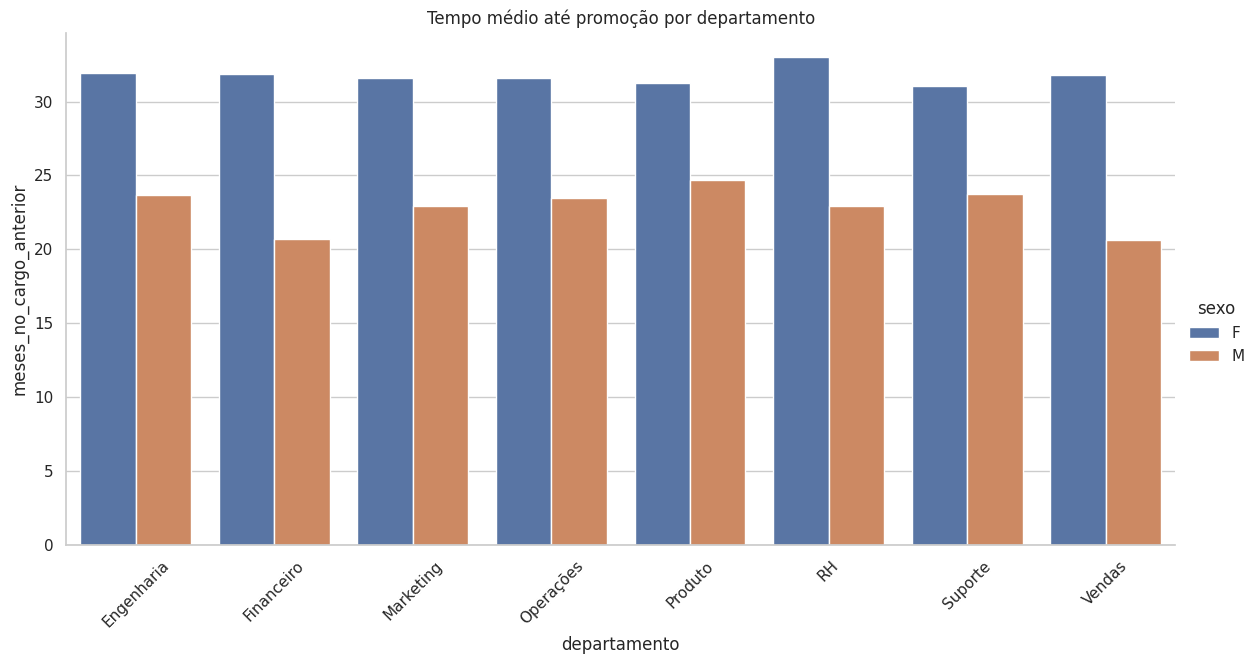

In [ ]:
# Aqui começam a aparecer padrões organizacionais (possível gestor tóxico)
tempo_departamento = df_historico_promocoes.groupby(
    ["departamento","sexo"]
)["meses_no_cargo_anterior"].mean().reset_index()

tempo_departamento.head()

sns.catplot(
    data=tempo_departamento,
    x="departamento",
    y="meses_no_cargo_anterior",
    hue="sexo",
    kind="bar",
    height=6,
    aspect=2
)

plt.xticks(rotation=45)

plt.title("Tempo médio até promoção por departamento")

plt.show()

`Diferença salarial nas promoções`

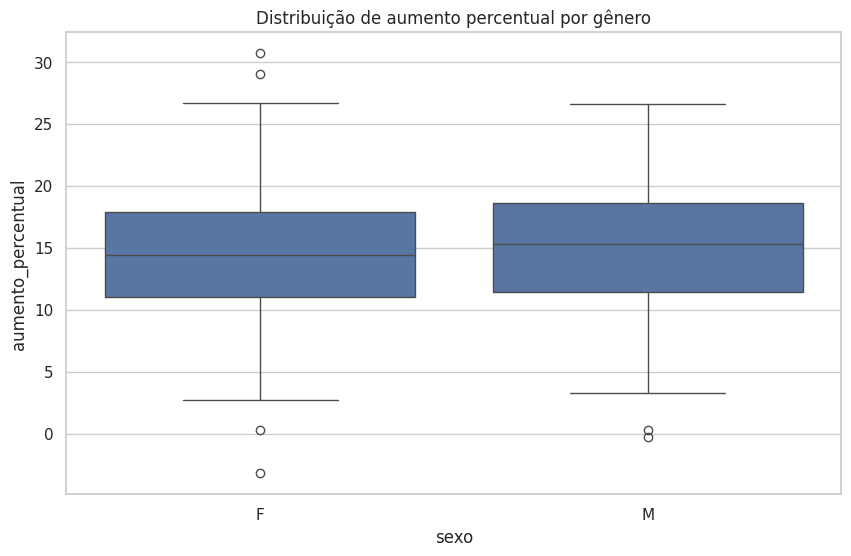

In [14]:
salario_genero = df_historico_promocoes.groupby("sexo")[
    ["salario_anterior","salario_novo","aumento_percentual"]
].mean()

salario_genero

sns.boxplot(
    data=df_historico_promocoes,
    x="sexo",
    y="aumento_percentual"
)

plt.title("Distribuição de aumento percentual por gênero")

plt.show()

`Proporção de promoções por gênero`

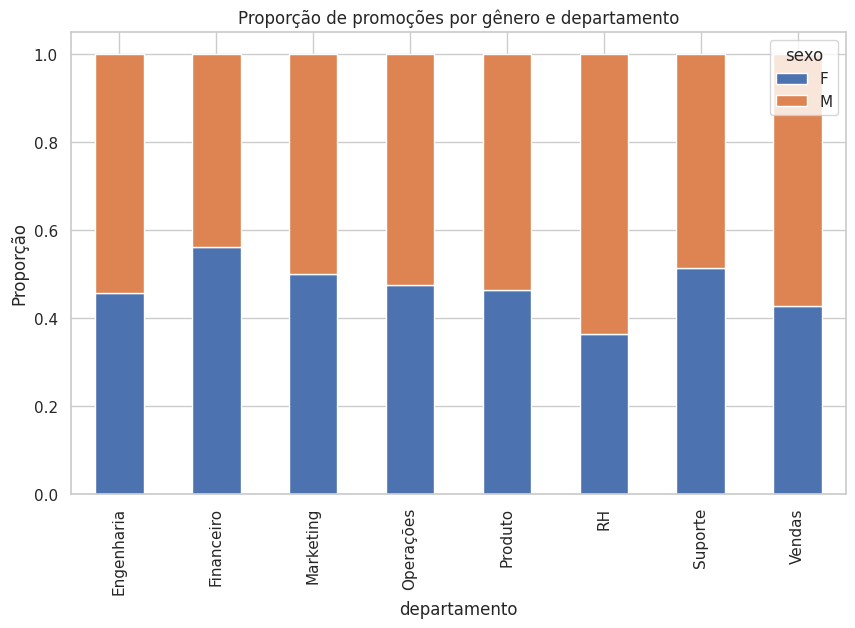

In [ ]:
promo_dept = pd.crosstab(
    df_historico_promocoes["departamento"],
    df_historico_promocoes["sexo"],
    normalize="index"
)

promo_dept.plot(
    kind="bar",
    stacked=True
)

plt.title("Proporção de promoções por gênero e departamento")

plt.ylabel("Proporção")

plt.show()

`Análise de coorte`

/tmp/ipykernel_735/302222852.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  coorte = df_historico_promocoes.groupby(


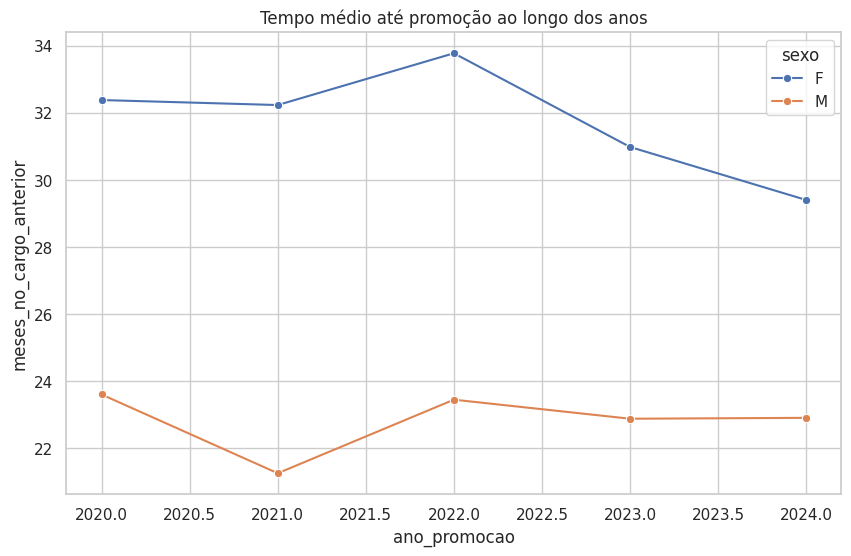

In [ ]:
df_historico_promocoes["ano_promocao"] = df_historico_promocoes["data_promocao"].dt.year
coorte = df_historico_promocoes.groupby(
    ["ano_promocao","sexo"]
)["meses_no_cargo_anterior"].mean().reset_index()

coorte.head()

sns.lineplot(
    data=coorte,
    x="ano_promocao",
    y="meses_no_cargo_anterior",
    hue="sexo",
    marker="o"
)

plt.title("Tempo médio até promoção ao longo dos anos")

plt.show()

`Função para calcular custo potencial de turnover`

In [ ]:
def custo_turnover(num_saidas, custo_por_saida=45000):
    return num_saidas * custo_por_saida

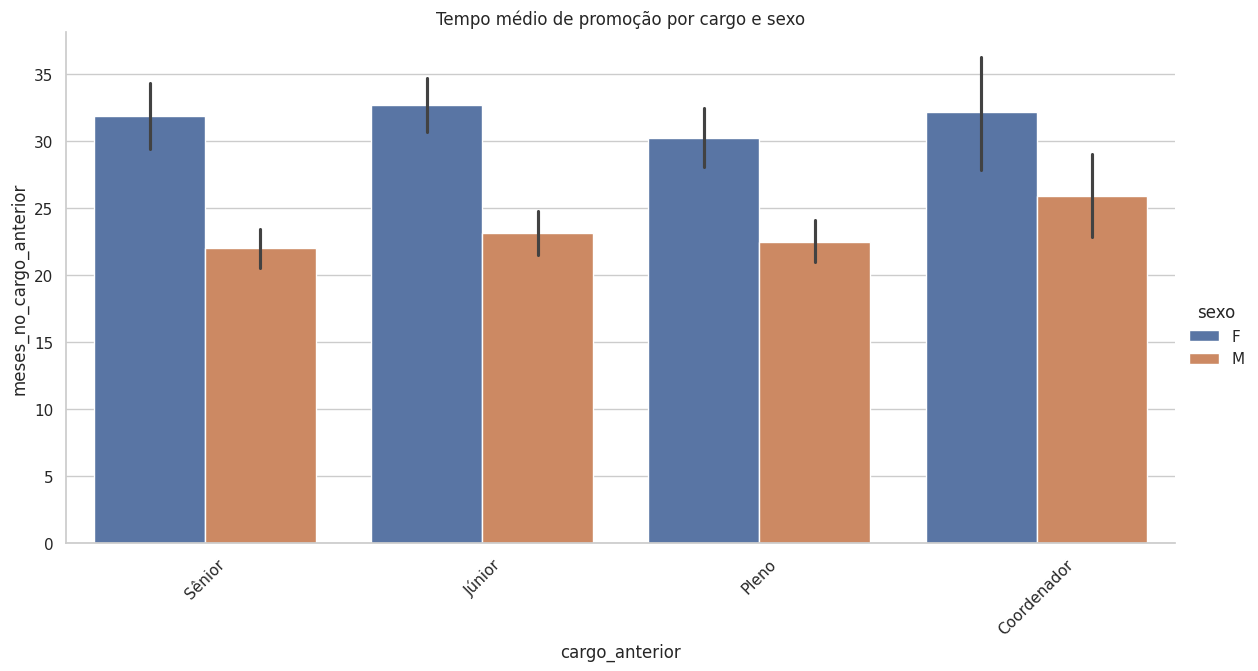

In [ ]:
# Tempo médio de promoção por cargo com a variação por sexo,

sns.catplot(
    data=df_historico_promocoes,
    x="cargo_anterior",
    y="meses_no_cargo_anterior",
    hue="sexo",
    kind="bar",
    height=6,
    aspect=2
)

plt.xticks(rotation=45)
plt.title("Tempo médio de promoção por cargo e sexo")
plt.show()

/tmp/ipykernel_735/2097986173.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  salario_medio = df_historico_promocoes.groupby(
/tmp/ipykernel_735/2097986173.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabela_salarios = salario_medio.pivot_table(


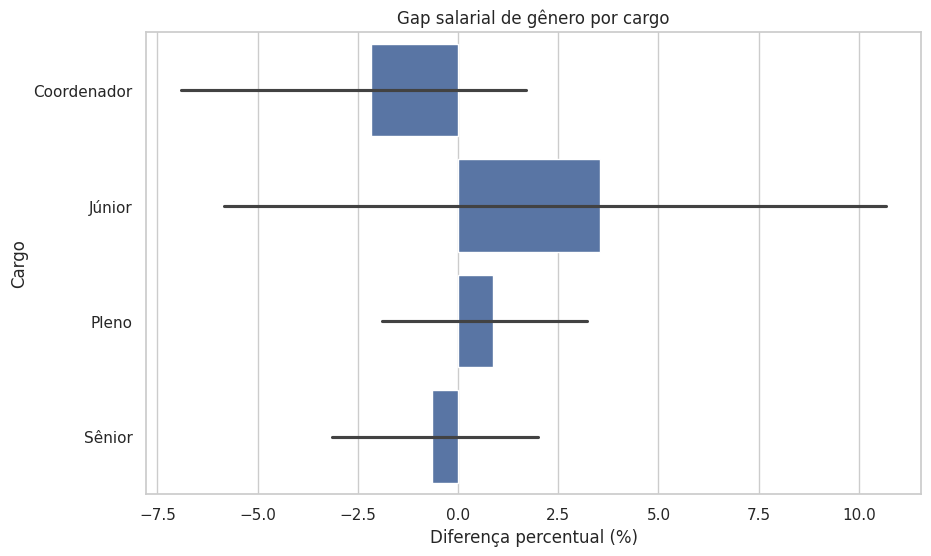

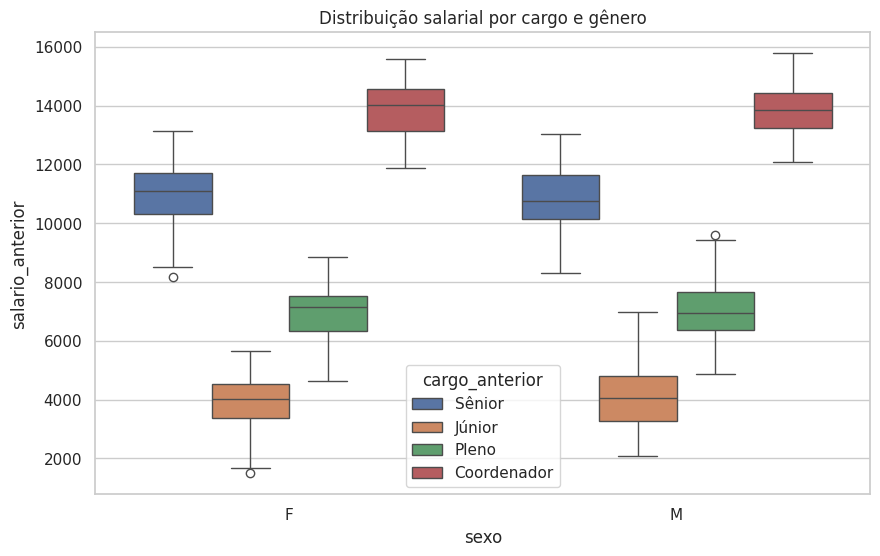

In [ ]:
# O ganho salarial do homem é maior do que o da mulher?

# Existe gap salarial de gênero? Compare salários de homens e mulheres no mesmo cargo e departamento. Quantifique a diferença.
# ou podemos seguir a ideia de comparar homens e mulheres no mesmo cargo e no mesmo departamento

salario_medio = df_historico_promocoes.groupby(
    ["departamento","cargo_anterior","sexo"]
)["salario_anterior"].mean().reset_index()

salario_medio.head()

tabela_salarios = salario_medio.pivot_table(
    index=["departamento","cargo_anterior"],
    columns="sexo",
    values="salario_anterior"
).reset_index()

tabela_salarios.head()

tabela_salarios["gap_salarial"] = tabela_salarios["M"] - tabela_salarios["F"]

tabela_salarios["gap_percentual"] = (
    (tabela_salarios["M"] - tabela_salarios["F"]) /
    tabela_salarios["M"]
) * 100

tabela_salarios.sort_values(
    by="gap_percentual",
    ascending=False
).head(10)

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=tabela_salarios,
    x="gap_percentual",
    y="cargo_anterior"
)

plt.title("Gap salarial de gênero por cargo")
plt.xlabel("Diferença percentual (%)")
plt.ylabel("Cargo")

plt.show()

sns.boxplot(
    data=df_historico_promocoes,
    x="sexo",
    y="salario_anterior",
    hue="cargo_anterior"
)

plt.title("Distribuição salarial por cargo e gênero")
plt.show()


```
# Análises cruzando as informações de:

*   tempo para promoção

*   salário após a promoção

*   gênero

```



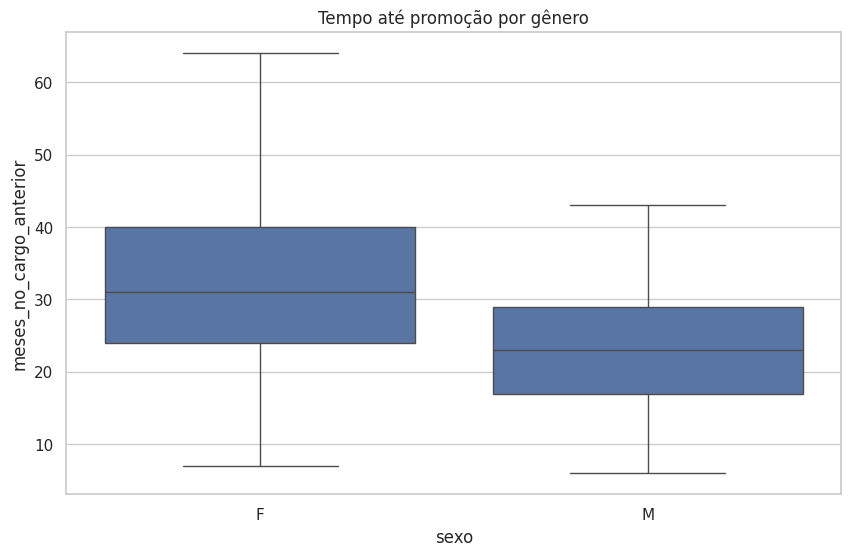

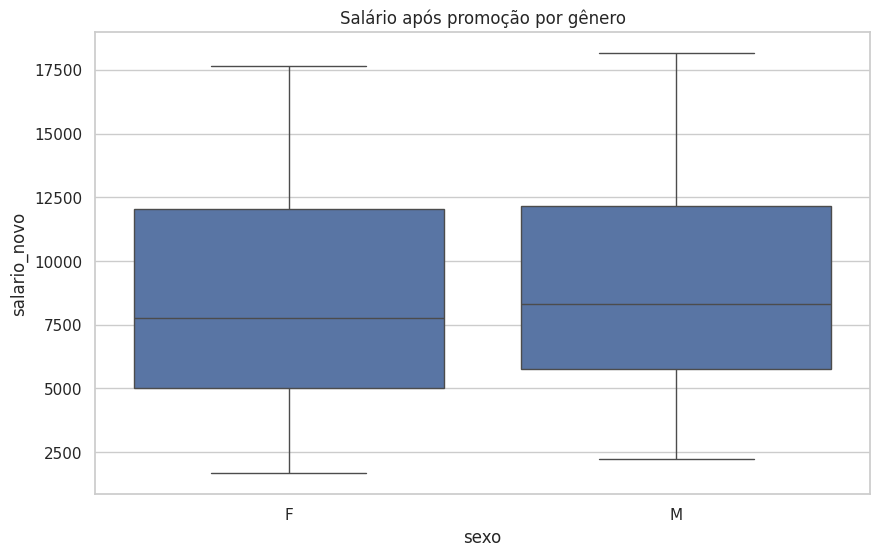

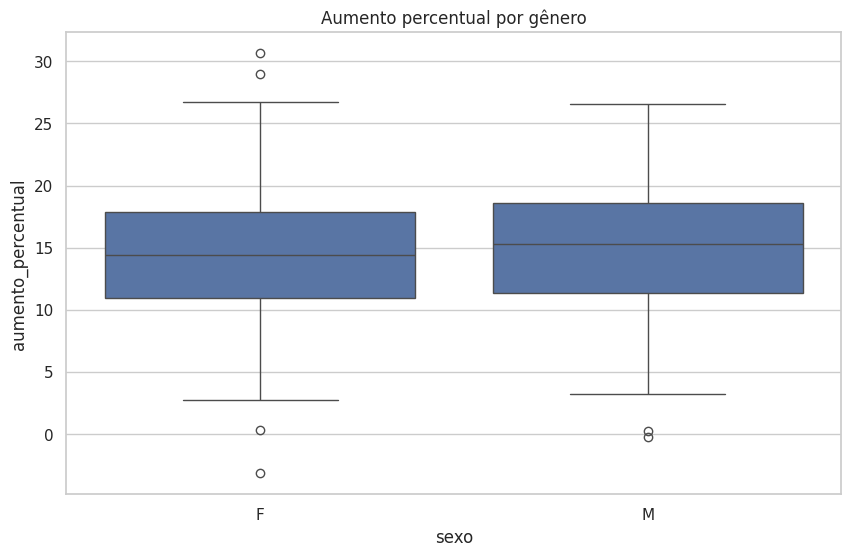

In [18]:
#Métrica para analisar

df_historico_promocoes["variacao_salarial"] = df_historico_promocoes["salario_novo"] - df_historico_promocoes["salario_anterior"]

df_historico_promocoes["aumento_percentual"] = (
    df_historico_promocoes["variacao_salarial"] / df_historico_promocoes["salario_anterior"]
) * 100

analise_genero = df_historico_promocoes.groupby("sexo").agg(

    tempo_medio_promocao=("meses_no_cargo_anterior","mean"),

    salario_medio_pos_promocao=("salario_novo","mean"),

    aumento_medio_percentual=("aumento_percentual","mean"),

    total_promocoes=("sexo","count")

)

analise_genero

#Visulizar o tempo e a promoção

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=df_historico_promocoes,
    x="sexo",
    y="meses_no_cargo_anterior"
)

plt.title("Tempo até promoção por gênero")
plt.show()

# Salário após promoção

sns.boxplot(
    data=df_historico_promocoes,
    x="sexo",
    y="salario_novo"
)

plt.title("Salário após promoção por gênero")
plt.show()

# Aumento salarial

sns.boxplot(
    data=df_historico_promocoes,
    x="sexo",
    y="aumento_percentual"
)

plt.title("Aumento percentual por gênero")
plt.show()

In [ ]:
# Cruzamento completo

analise_cruzada = df_historico_promocoes.groupby(
    ["cargo_anterior","sexo"]
).agg(

    tempo_promocao=("meses_no_cargo_anterior","mean"),

    salario_pos_promocao=("salario_novo","mean"),

    aumento_percentual=("aumento_percentual","mean"),

    quantidade=("sexo","count")

).reset_index()

analise_cruzada.head()

/tmp/ipykernel_735/3352692219.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analise_cruzada = df_historico_promocoes.groupby(


,cargo_anterior,sexo,tempo_promocao,salario_pos_promocao,aumento_percentual,quantidade
0,Coordenador,F,32.173913,15831.683478,14.078995,23
1,Coordenador,M,25.931034,15787.451034,14.439780,29
2,Júnior,F,32.685185,4489.114352,14.370894,108
3,Júnior,M,23.153061,4728.095102,15.124061,98
4,Pleno,F,30.229885,7919.074023,14.092542,87


/tmp/ipykernel_735/336299440.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_gap = analise_cruzada.pivot_table(


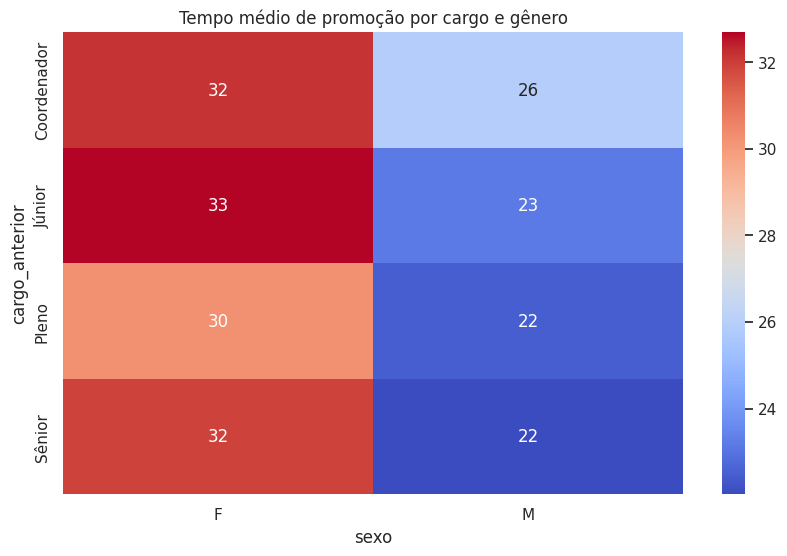

In [ ]:
#Heatmap da desigualdade

pivot_gap = analise_cruzada.pivot_table(
    index="cargo_anterior",
    columns="sexo",
    values="tempo_promocao"
)

sns.heatmap(pivot_gap, annot=True, cmap="coolwarm")

plt.title("Tempo médio de promoção por cargo e gênero")

plt.show()

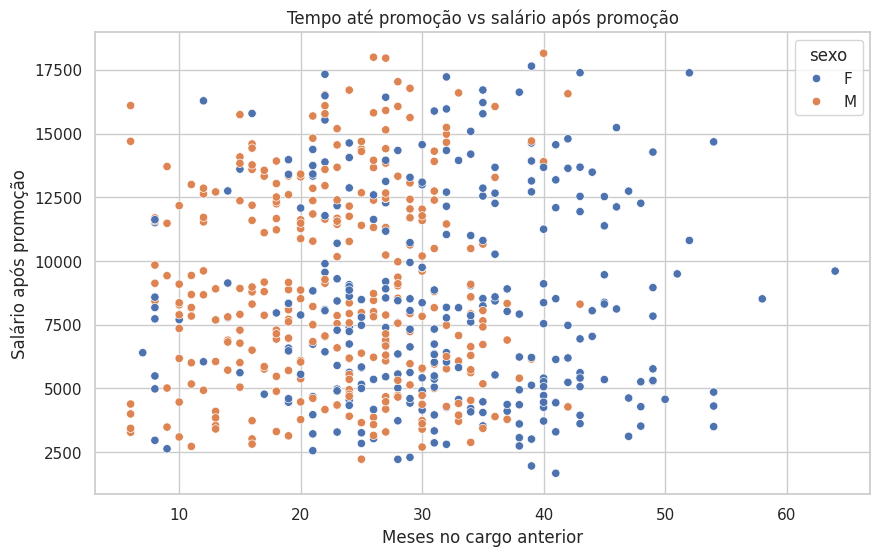

In [ ]:
#Scatter da progressão de carreira

sns.scatterplot(
    data=df_historico_promocoes,
    x="meses_no_cargo_anterior",
    y="salario_novo",
    hue="sexo"
)

plt.title("Tempo até promoção vs salário após promoção")

plt.xlabel("Meses no cargo anterior")

plt.ylabel("Salário após promoção")

plt.show()

sexo
F    31.709220
M    22.874214
Name: meses_no_cargo_anterior, dtype: float64
Tempo médio mulheres: 31.70921985815603
Tempo médio homens: 22.87421383647799
Gap percentual: 38.624304576486345


/tmp/ipykernel_735/2783888585.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tempo_promocao = df_historico_promocoes.groupby("sexo")["meses_no_cargo_anterior"].mean()


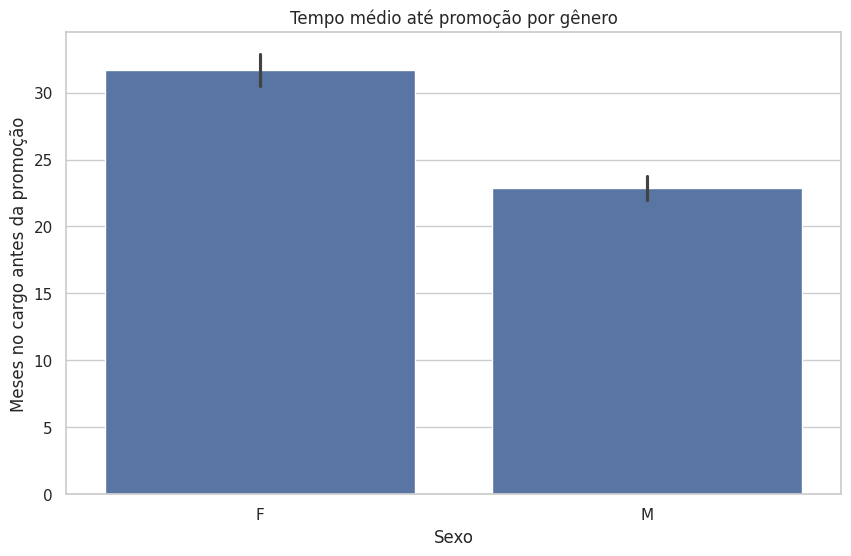

In [ ]:
# No histórico de promoções, compare meses_no_cargo_anterior por sexo — mulheres esperam ~40% mais?

tempo_promocao = df_historico_promocoes.groupby("sexo")["meses_no_cargo_anterior"].mean()

print(tempo_promocao)

media_mulheres = tempo_promocao["F"]
media_homens = tempo_promocao["M"]

gap_percentual = ((media_mulheres - media_homens) / media_homens) * 100

print("Tempo médio mulheres:", media_mulheres)
print("Tempo médio homens:", media_homens)
print("Gap percentual:", gap_percentual)

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=df_historico_promocoes,
    x="sexo",
    y="meses_no_cargo_anterior",
    estimator="mean"
)

plt.title("Tempo médio até promoção por gênero")
plt.xlabel("Sexo")
plt.ylabel("Meses no cargo antes da promoção")

plt.show()

# Interpretação analítica:

# se mulheres > homens, existe atraso na progressão de carreira

# se a diferença for ≈40%, é um gap relevante

# se o padrão aparecer em vários cargos ou departamentos, pode indicar desigualdade estrutural